In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [2]:
df = pd.read_excel("premiums_with_life_style.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459


In [3]:
df.shape

(10000, 15)

In [4]:
df.isna().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Physical_Activity         0
Stress_Level              0
Number Of Dependants      0
BMI_Category              0
Smoking_Status            9
Employment_Status         7
Income_Level             18
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [5]:
df.dropna(inplace=True)
df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Physical_Activity        0
Stress_Level             0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,9973.000000,9973.000000,9973.000000,9973.000000
mean,41.319362,3.195628,23.382232,19503.816705
std,58.044687,21.679565,32.334811,8898.079736
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11774.000000
50%,37.000000,2.000000,16.000000,19314.000000
75%,50.000000,3.000000,31.000000,26500.000000
max,1178.000000,456.000000,960.000000,45854.000000


In [8]:
df[df['Number Of Dependants']>10]['Number Of Dependants'].unique()

array([456,  78, 230])

In [9]:
df = df[df["Number Of Dependants"] <= 10]

In [10]:
df = df[df["Age"] <= 100]

In [11]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,9868.000000,9868.000000,9868.000000,9868.000000
mean,37.756486,1.919133,23.411634,19511.417714
std,13.976822,1.503264,32.437621,8900.941540
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11776.250000
50%,37.000000,2.000000,16.000000,19327.500000
75%,50.000000,3.000000,31.000000,26505.250000
max,72.000000,5.000000,960.000000,45854.000000


In [12]:
quantile_thresold = df.Income_Lakhs.quantile(0.999)
quantile_thresold

np.float64(155.86000000068452)

In [13]:
df[df.Income_Lakhs>quantile_thresold].shape

(10, 15)

In [14]:
df = df[df.Income_Lakhs<=quantile_thresold].copy()
df.shape

(9858, 15)

In [15]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns  

Index(['Age', 'Number Of Dependants', 'Income_Lakhs', 'Annual_Premium_Amount'], dtype='object')

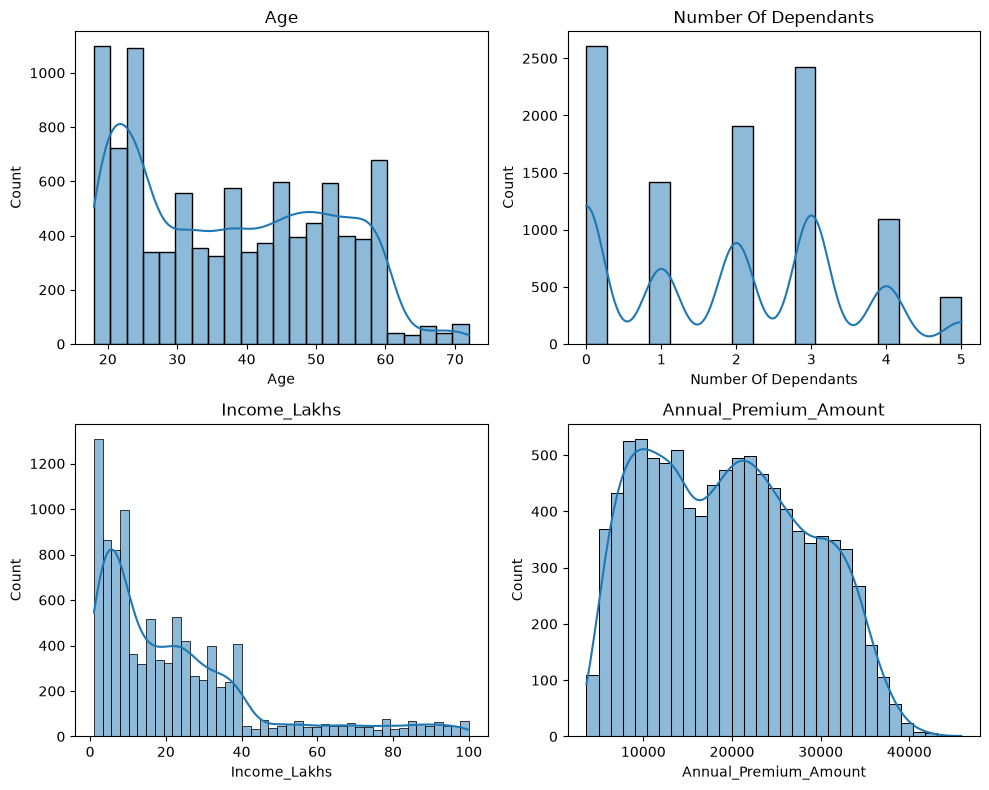

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

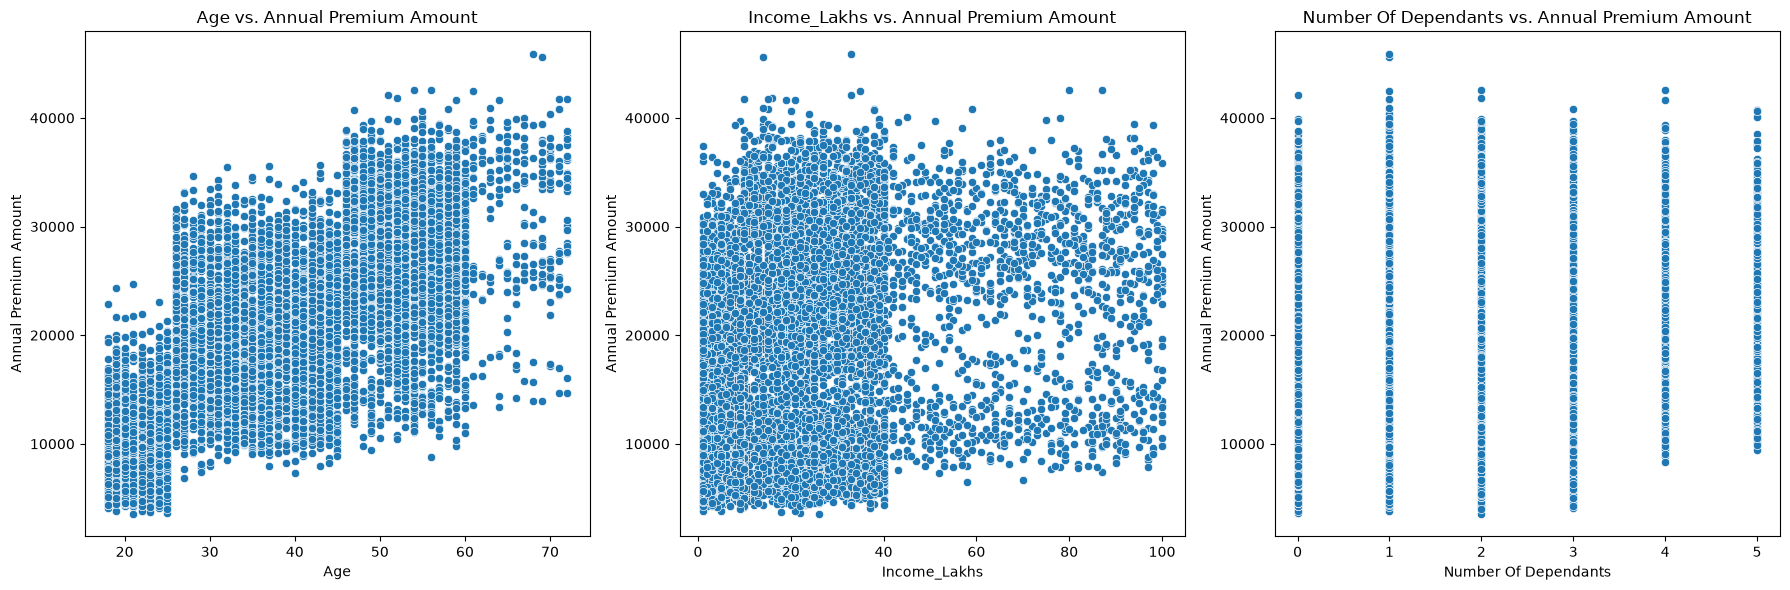

In [17]:
numeric_features = ['Age', 'Income_Lakhs', 'Number Of Dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df[column], y=df['Annual_Premium_Amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

In [18]:
df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Physical_Activity        0
Stress_Level             0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

In [19]:
categorical_cols = ['Gender', 'Region', 'Marital_status', 'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level', 'Medical History', 'Insurance_Plan','Physical_Activity','Stress_Level']
for col in categorical_cols:
    print(col, ":", df[col].unique())

Gender : ['Female' 'Male']
Region : ['Southeast' 'Northeast' 'Southwest' 'Northwest']
Marital_status : ['Unmarried' 'Married']
BMI_Category : ['Normal' 'Overweight' 'Obesity' 'Underweight']
Smoking_Status : ['No Smoking' 'Occasional' 'Regular']
Employment_Status : ['Self-Employed' 'Freelancer' 'Salaried']
Income_Level : ['25L - 40L' '10L - 25L' '<10L' '> 40L']
Medical History : ['High blood pressure' 'No Disease' 'Thyroid'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid' 'Diabetes'
 'Heart disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease']
Insurance_Plan : ['Gold' 'Silver' 'Bronze']
Physical_Activity : ['Medium' 'Low' 'High']
Stress_Level : ['Medium' 'High' 'Low']


In [20]:
df['Smoking_Status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
}, inplace=True)

df['Smoking_Status'].unique()

C:\Users\Nikhil\AppData\Local\Temp\ipykernel_18812\2570960751.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Smoking_Status'].replace({


array(['No Smoking', 'Occasional', 'Regular'], dtype=object)

In [21]:
df.head(2)

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108


In [22]:
# Define risk scores
disease_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure": 6,
    "thyroid": 5,
    "no disease": 0,
    "none": 0
}

physical_activity_scores = {
    "High": 0,
    "Medium": 1,
    "Low": 4
}

stress_level_scores = {
    "High": 4,
    "Medium": 1,
    "Low": 0
}

# Split medical history into two diseases
df[['disease1', 'disease2']] = (
    df['Medical History']
    .str.split(' & ', expand=True)
    .apply(lambda x: x.str.lower())
)

df['disease1'] = df['disease1'].fillna('none')
df['disease2'] = df['disease2'].fillna('none')

# Calculate total risk score
df['total_risk_score'] = (
    df['disease1'].map(disease_scores).fillna(0) +
    df['disease2'].map(disease_scores).fillna(0) +
    df['Physical_Activity'].map(physical_activity_scores).fillna(0) +
    df['Stress_Level'].map(stress_level_scores).fillna(0)
)

# Normalize the total risk score
df['normalized_risk_score'] = (
    (df['total_risk_score'] - df['total_risk_score'].min()) /
    (df['total_risk_score'].max() - df['total_risk_score'].min())
)

df.head()

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,high blood pressure,none,8,0.363636
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,no disease,none,8,0.363636
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,no disease,none,5,0.227273
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,thyroid,none,6,0.272727
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,high blood pressure,heart disease,19,0.863636


In [23]:
df['Insurance_Plan'] = df['Insurance_Plan'].map({'Gold': 3,'Silver': 2,'Bronze': 1})

In [24]:
df.Income_Level.unique()

array(['25L - 40L', '10L - 25L', '<10L', '> 40L'], dtype=object)

In [25]:
df['Income_Level'] = df['Income_Level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [27]:
nominal_cols = ['Gender', 'Region', 'Marital_status', 'BMI_Category', 'Smoking_Status', 'Employment_Status']
df2 = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df2.head(3)

,Age,Physical_Activity,Stress_Level,Number Of Dependants,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,disease1,...,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
0,56,Medium,Medium,2,3,37,High blood pressure,3,27944,high blood pressure,...,1,0,1,0,0,0,0,0,0,1
1,38,Low,High,5,2,10,No Disease,2,21108,no disease,...,0,0,0,0,1,0,1,0,0,0
2,18,Medium,High,0,1,9,No Disease,1,8459,no disease,...,0,1,1,0,0,0,0,0,0,0


In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9858 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              9858 non-null   int64  
 1   Physical_Activity                9858 non-null   object 
 2   Stress_Level                     9858 non-null   object 
 3   Number Of Dependants             9858 non-null   int64  
 4   Income_Level                     9858 non-null   int64  
 5   Income_Lakhs                     9858 non-null   int64  
 6   Medical History                  9858 non-null   object 
 7   Insurance_Plan                   9858 non-null   int64  
 8   Annual_Premium_Amount            9858 non-null   int64  
 9   disease1                         9858 non-null   object 
 10  disease2                         9858 non-null   object 
 11  total_risk_score                 9858 non-null   int64  
 12  normalized_risk_score    

In [33]:
df3 = df2.drop(['Medical History','disease1', 'disease2', 'total_risk_score','Physical_Activity','Stress_Level'], axis=1)
df3.head(3)                

,Age,Number Of Dependants,Income_Level,Income_Lakhs,Insurance_Plan,Annual_Premium_Amount,normalized_risk_score,Gender_Male,Region_Northwest,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
0,56,2,3,37,3,27944,0.363636,0,0,1,0,1,0,0,0,0,0,0,1
1,38,5,2,10,2,21108,0.363636,0,0,0,0,0,0,1,0,1,0,0,0
2,18,0,1,9,1,8459,0.227273,0,0,0,1,1,0,0,0,0,0,0,0


In [34]:
df3.columns

Index(['Age', 'Number Of Dependants', 'Income_Level', 'Income_Lakhs',
       'Insurance_Plan', 'Annual_Premium_Amount', 'normalized_risk_score',
       'Gender_Male', 'Region_Northwest', 'Region_Southeast',
       'Region_Southwest', 'Marital_status_Unmarried', 'BMI_Category_Obesity',
       'BMI_Category_Overweight', 'BMI_Category_Underweight',
       'Smoking_Status_Occasional', 'Smoking_Status_Regular',
       'Employment_Status_Salaried', 'Employment_Status_Self-Employed'],
      dtype='object')

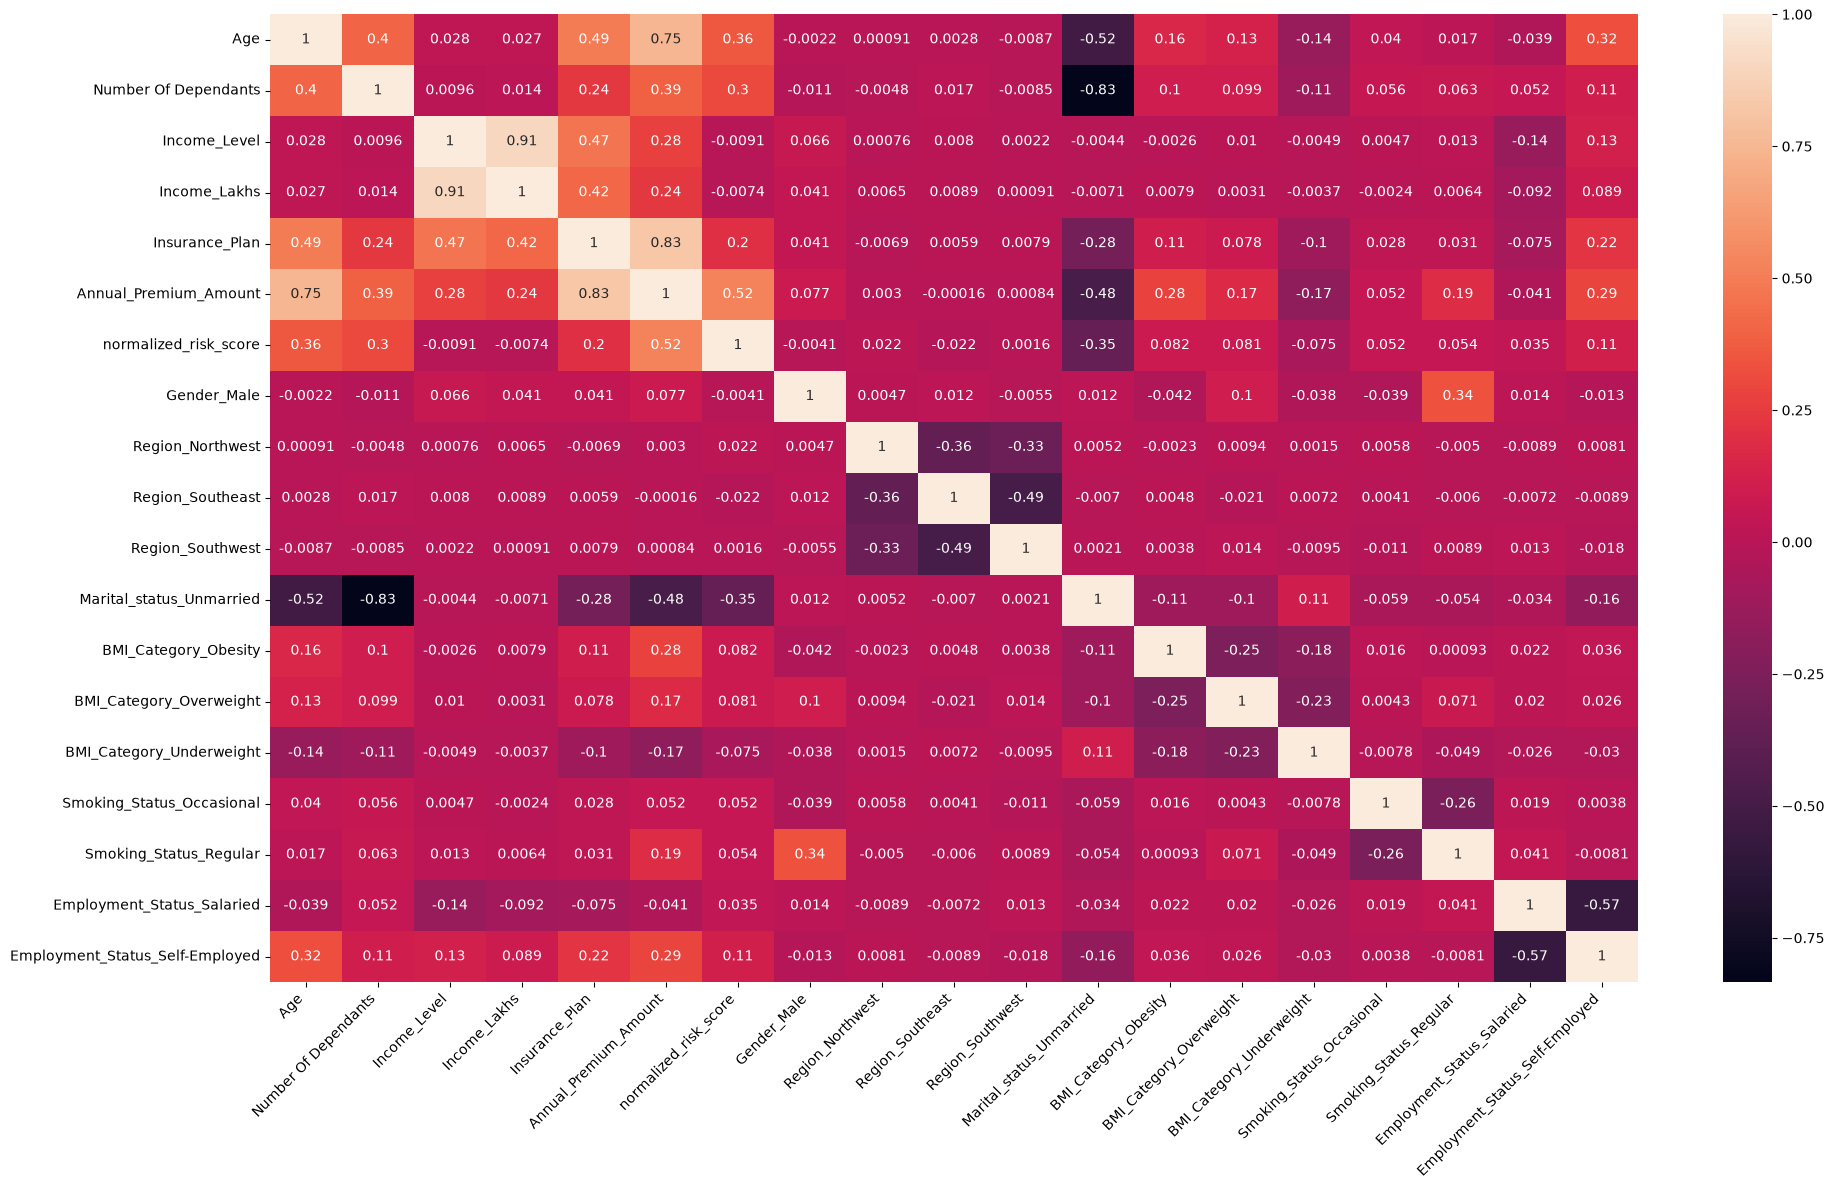

In [35]:
cm = df3.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [37]:
X = df3.drop('Annual_Premium_Amount', axis='columns')
y = df3['Annual_Premium_Amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['Age','Number Of Dependants','Income_Level', 'Income_Lakhs', 'Insurance_Plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,Age,Number Of Dependants,Income_Level,Income_Lakhs,Insurance_Plan,normalized_risk_score,Gender_Male,Region_Northwest,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
count,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000
mean,0.366014,0.383993,0.360756,0.219027,0.446135,0.356287,0.401298,0.194664,0.353013,0.306452,0.437716,0.167985,0.240414,0.141712,0.150030,0.278657,0.420065,0.308176
std,0.258820,0.300605,0.352198,0.226801,0.395765,0.202546,0.490186,0.395962,0.477931,0.461043,0.496131,0.373872,0.427356,0.348773,0.357119,0.448361,0.493594,0.461763
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.111111,0.000000,0.000000,0.050505,0.000000,0.227273,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.351852,0.400000,0.333333,0.151515,0.500000,0.363636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.592593,0.600000,0.666667,0.303030,1.000000,0.500000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [38]:
calculate_vif(X)

,Column,VIF
0,Age,5.519355
1,Number Of Dependants,5.287355
2,Income_Level,12.545841
3,Income_Lakhs,10.947287
4,Insurance_Plan,4.146919
5,normalized_risk_score,4.614450
6,Gender_Male,1.909401
7,Region_Northwest,2.078182
8,Region_Southeast,2.943085
9,Region_Southwest,2.671108


In [40]:
calculate_vif(X.drop('Income_Level', axis="columns"))

,Column,VIF
0,Age,5.465453
1,Number Of Dependants,5.272828
2,Income_Lakhs,2.448484
3,Insurance_Plan,3.875294
4,normalized_risk_score,4.614211
5,Gender_Male,1.900816
6,Region_Northwest,2.077977
7,Region_Southeast,2.942058
8,Region_Southwest,2.669990
9,Marital_status_Unmarried,3.032948


In [41]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop('Income_Level', axis="columns")

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (6900, 17)
x test:  (2958, 17)
y train:  (6900,)
y test:  (2958,)


In [43]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9579901005751459, 0.9564081019290896)

In [44]:
X_test.shape

(2958, 17)

In [45]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([10561.505714,  -694.620766,  -691.613773, 13314.54656 ,
       10989.645121,    13.454885,    73.058641,    89.642701,
         -10.218604,  -753.712274,  4156.828797,  2104.9435  ,
         424.076281,  1135.956127,  3111.478408,    -8.872325,
         364.5271  ])

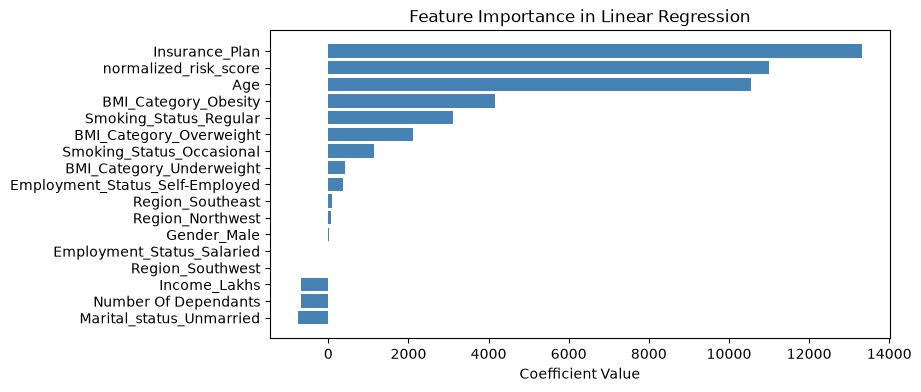

In [46]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [47]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9849156737327576

In [48]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9883243441581726)

In [49]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [50]:
best_model = model_lr

In [51]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
3021,13354,13683.901066,329.901066,2.470429
6049,10701,11314.056623,613.056623,5.728966
6146,15146,16520.845705,1374.845705,9.077286
6418,8743,8205.562579,-537.437421,-6.147060
1537,27887,29007.047181,1120.047181,4.016377


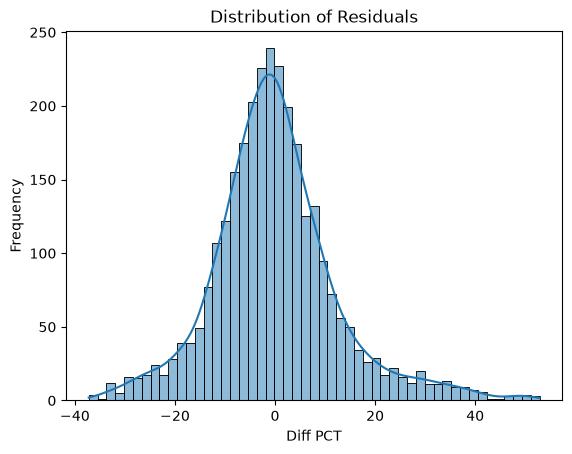

In [52]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [53]:
X_test.shape

(2958, 17)

In [54]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
1439,20096,22465.820530,2369.820530,11.792499
8330,10733,9613.186739,-1119.813261,-10.433367
895,8832,10666.453234,1834.453234,20.770530
7800,9632,7515.237415,-2116.762585,-21.976356
8061,7535,6502.924859,-1032.075141,-13.697082


In [55]:
extreme_results_df.shape

(953, 4)

In [56]:
extreme_results_df.shape[0]*100/X_test.shape[0]

32.21771467207573

In [57]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,Age,Number Of Dependants,Income_Lakhs,Insurance_Plan,normalized_risk_score,Gender_Male,Region_Northwest,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
1439,0.425926,0.4,0.010101,0.0,0.772727,1,0,1,0,0,0,1,0,0,1,0,1
8330,0.111111,0.0,0.060606,0.0,0.090909,1,0,0,1,1,1,0,0,0,0,0,0


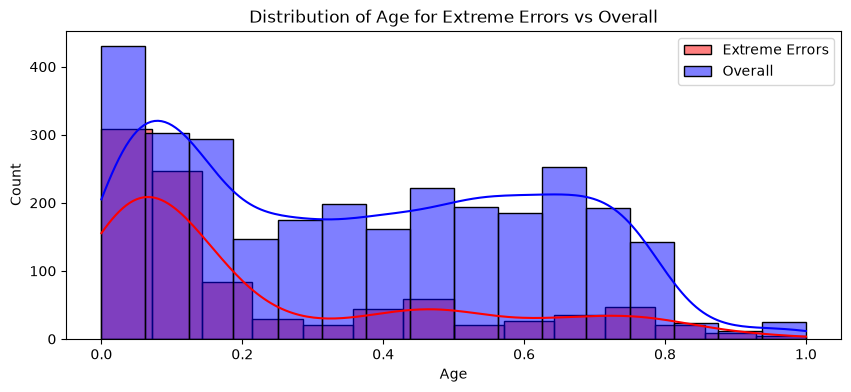

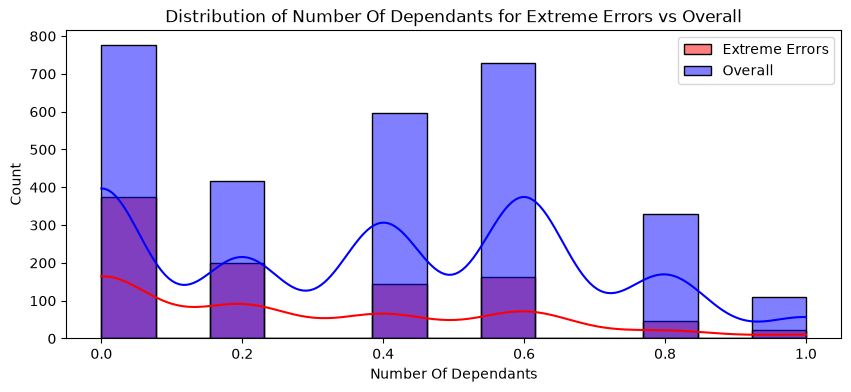

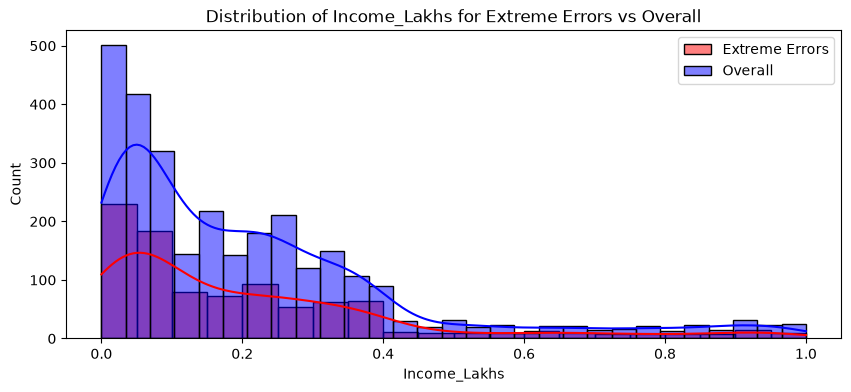

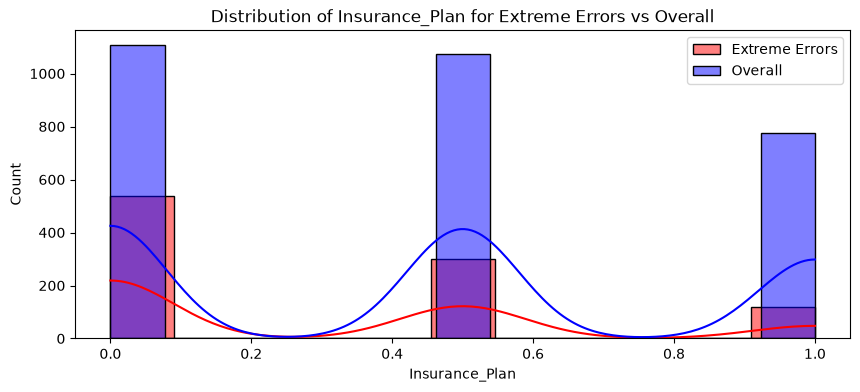

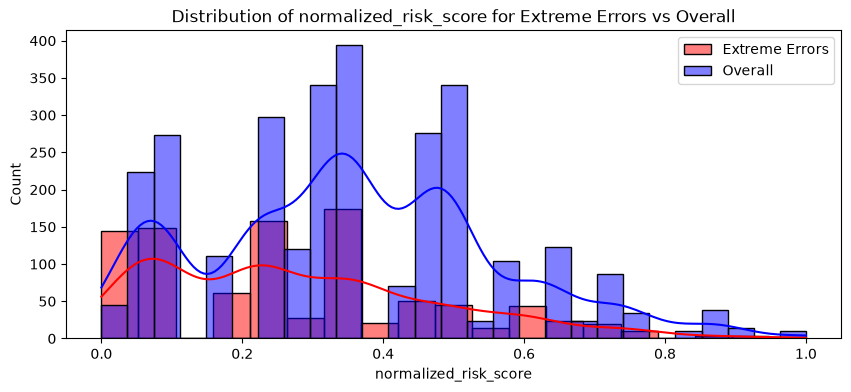

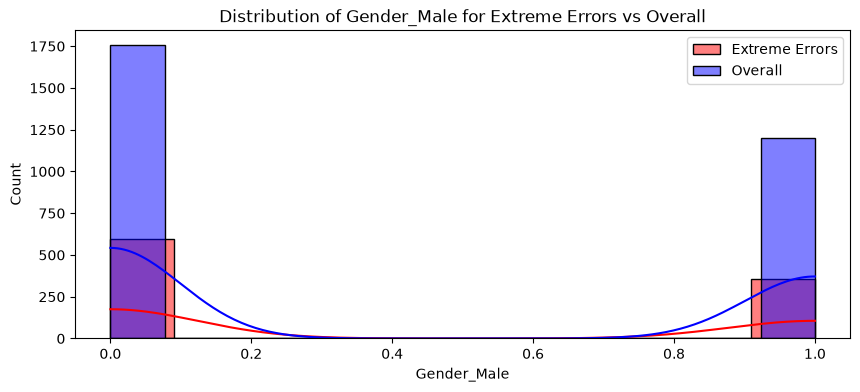

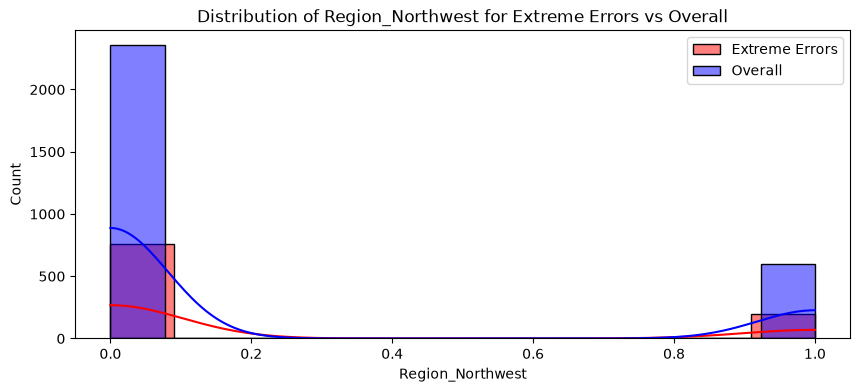

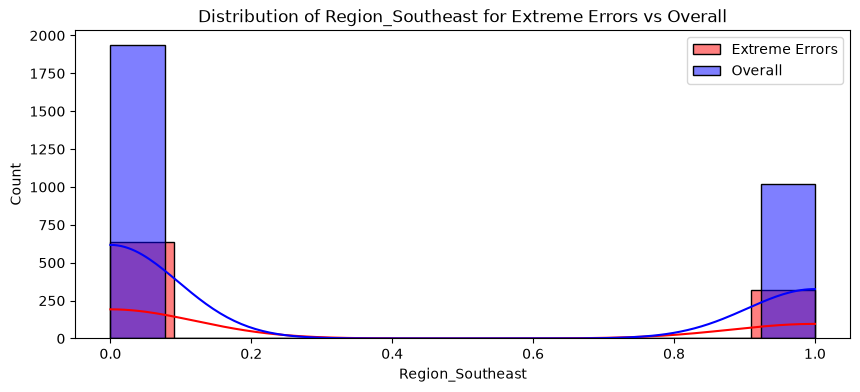

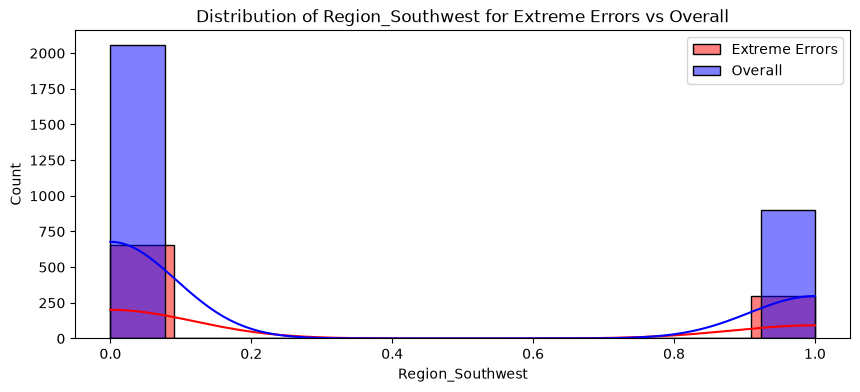

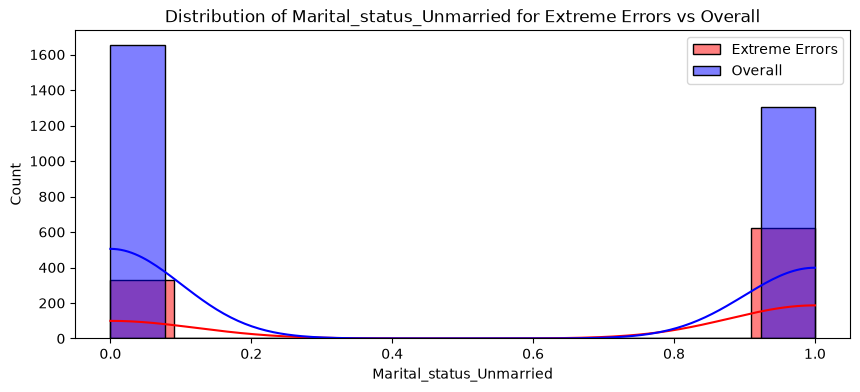

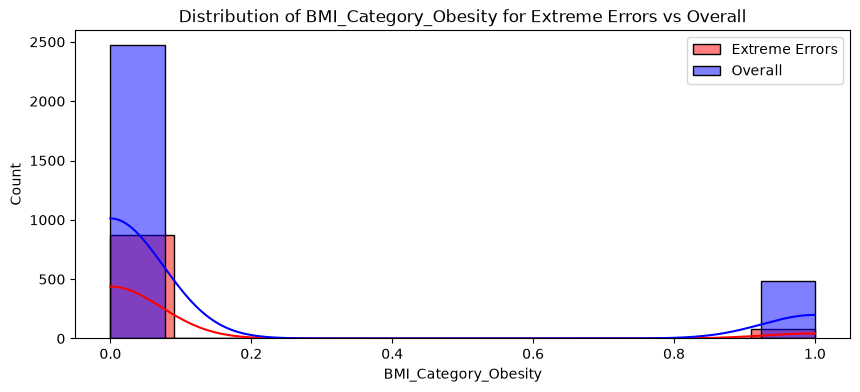

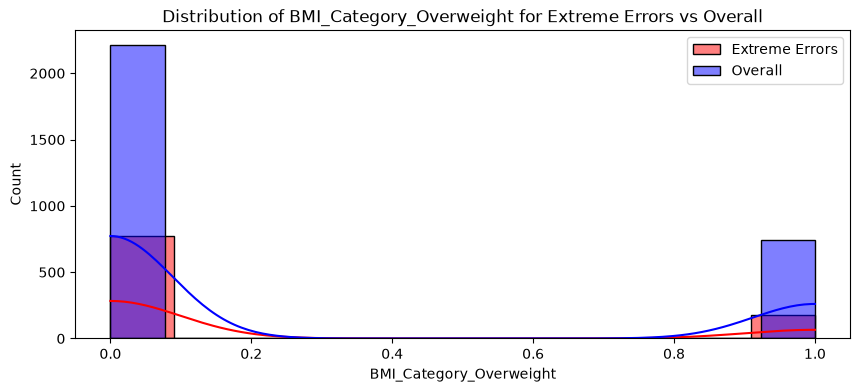

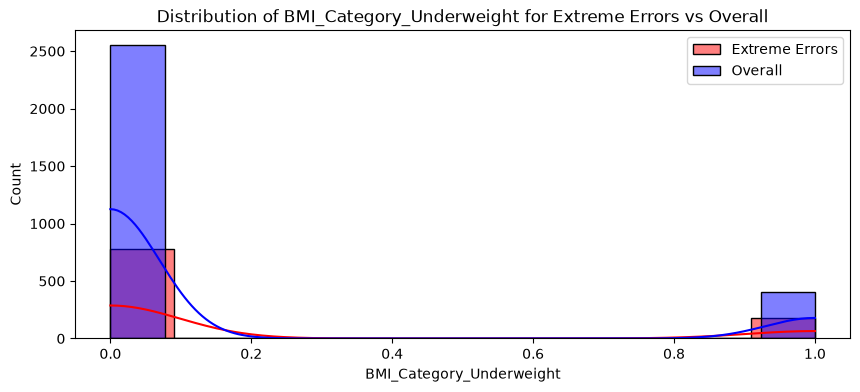

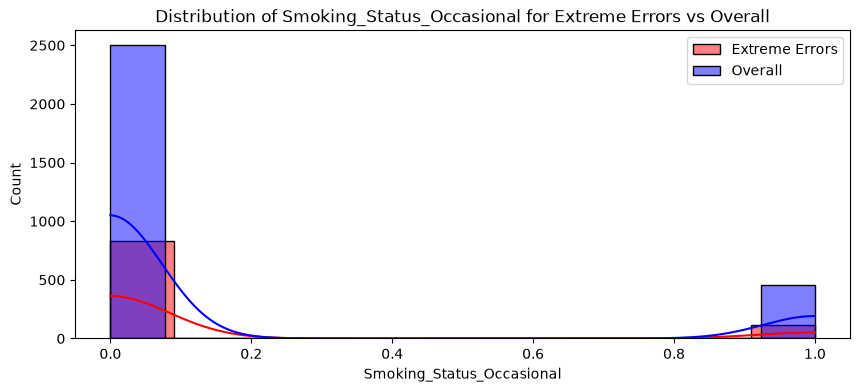

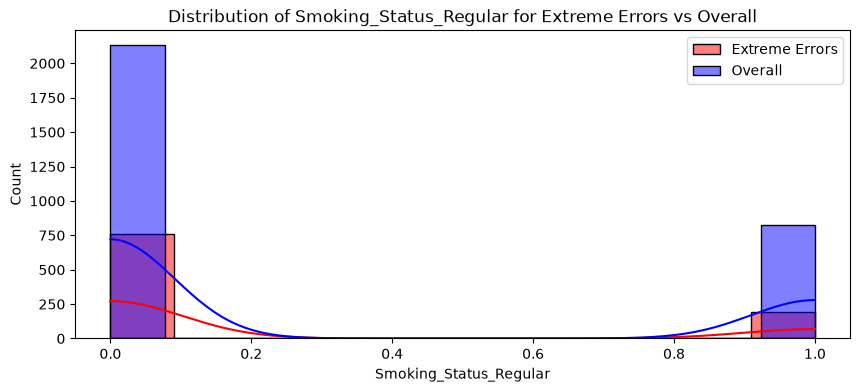

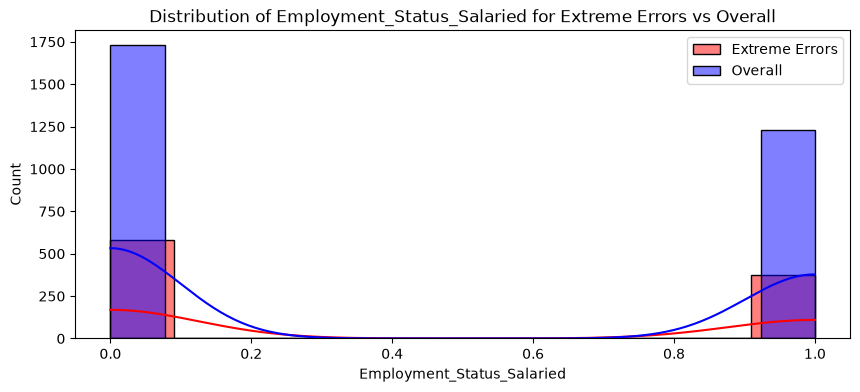

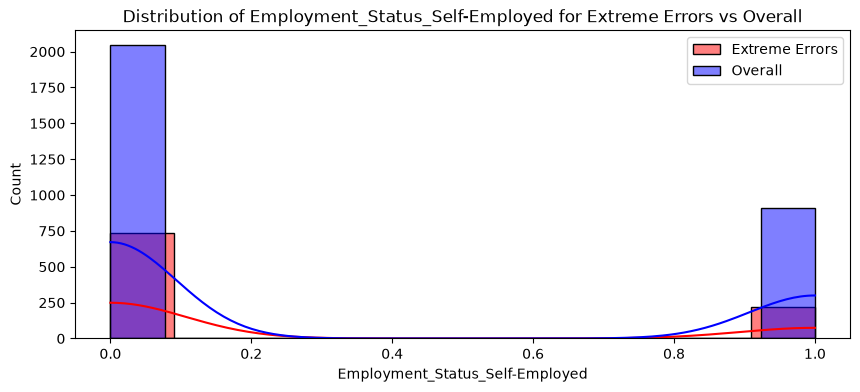

In [58]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [59]:
from joblib import dump

dump(best_model, "artifacts/model_lifeStyle.joblib")
scaler_with_cols = {
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(scaler_with_cols, "artifacts/scaler_lifeStyle.joblib")

['artifacts/scaler_lifeStyle.joblib']